# Hipotese H2 - periodos intensos e sinistros fatais

H2 avalia se fins de semana, feriados nacionais e meses de ferias (janeiro, julho e dezembro) concentram maior frequencia de sinistros e maior proporcao de ocorrencias fatais.

In [1]:
from pathlib import Path
from prf_sdk.analysis.hypotheses.h2 import run_h2_analysis

result = run_h2_analysis()
result['status'], result['evidence'], result['support_metric']

('Validada',
 'Periodos intensos registram 201.2 sinistros/dia contra 178.8 nos demais dias, com proporcao fatal de 7.74% contra 6.56%.',
 'Teste z de duas proporcoes: z=12.59, p=2.34e-36, RR=1.181.')

In [2]:
summary = result['summary'].copy()
summary['proporcao_fatal_pct'] = summary['proporcao_fatal'] * 100

if 'sinistros_fatais_por_dia' not in summary.columns:
    summary['sinistros_fatais_por_dia'] = (
        summary['sinistros_fatais'] / summary['dias_observados']
    )

summary[['recorte', 'grupo', 'dias_observados', 'sinistros', 'sinistros_por_dia', 'sinistros_fatais', 'sinistros_fatais_por_dia', 'proporcao_fatal_pct', 'mortos']]

,recorte,grupo,dias_observados,sinistros,sinistros_por_dia,sinistros_fatais,sinistros_fatais_por_dia,proporcao_fatal_pct,mortos
0,Fim de semana,Fim de semana,452,97558,215.836283,8114,17.951327,8.317104,9586
1,Fim de semana,Demais dias - Fim de semana,1129,202528,179.387068,13415,11.882197,6.623775,15550
2,Feriado nacional,Feriado nacional,55,10341,188.018182,811,14.745455,7.842568,947
3,Feriado nacional,Demais dias - Feriado nacional,1526,289745,189.872215,20718,13.576671,7.150425,24189
4,Ferias (jan/jul/dez),Ferias (jan/jul/dez),403,77166,191.478908,5569,13.818859,7.216909,6654
5,Ferias (jan/jul/dez),Demais dias - Ferias (jan/jul/dez),1178,222920,189.235993,15960,13.548387,7.159519,18482
6,Periodo intenso (qualquer),Periodo intenso (qualquer),776,156123,201.189433,12090,15.579897,7.743894,14273
7,Periodo intenso (qualquer),Demais dias - Periodo intenso (qualquer),805,143963,178.836025,9439,11.725466,6.556546,10863


In [3]:
tests = result['tests'].copy()
tests[['group', 'group_n', 'reference_n', 'group_rate', 'reference_rate', 'difference', 'relative_risk', 'z_statistic', 'p_value']]

,group,group_n,reference_n,group_rate,reference_rate,difference,relative_risk,z_statistic,p_value
0,Fim de semana,97558,202528,0.083171,0.066238,0.016933,1.255644,16.837167,1.303283e-63
1,Feriado nacional,10341,289745,0.078426,0.071504,0.006921,1.096797,2.680026,7.361645e-03
2,Ferias (jan/jul/dez),77166,222920,0.072169,0.071595,0.000574,1.008016,0.532448,5.944161e-01
3,"Periodo intenso (fim de semana, feriado ou fer...",156123,143963,0.077439,0.065565,0.011873,1.181094,12.591892,2.339974e-36


## Interpretacao

A hipotese foi validada para o indicador composto de periodo intenso: fins de semana, feriados ou meses de ferias apresentam maior frequencia diaria de sinistros e maior proporcao de sinistros fatais em relacao aos demais dias. A dimensao de ferias isolada tem aumento pequeno e sem significancia estatistica na proporcao fatal, portanto o efeito agregado e puxado principalmente por fins de semana e feriados.

## Decomposição STL — Sazonalidade Mensal

Verificamos se a sazonalidade mensal se manifesta no **volume** de sinistros ou na **gravidade** (proporção fatal).
A decomposição STL-LOESS separa a série em tendência, componente sazonal (período = 12 meses) e resíduo.

In [4]:
stl_vol = result['stl_volume']
stl_sev = result['stl_severity']

print("Variância explicada pela componente sazonal:")
print(f"  Volume mensal      : {stl_vol['pct_variance_seasonal']:.1%}")
print(f"  Proporção fatal    : {stl_sev['pct_variance_seasonal']:.1%}")
print()
print(f"Figura STL salva em: {result['stl_figure_path']}")

Variância explicada pela componente sazonal:
  Volume mensal      : 38.2%
  Proporção fatal    : 67.1%

Figura STL salva em: /home/thomruby/Documents/prf-analise-sinistros/docs/figures/h2_stl_decomposicao.png


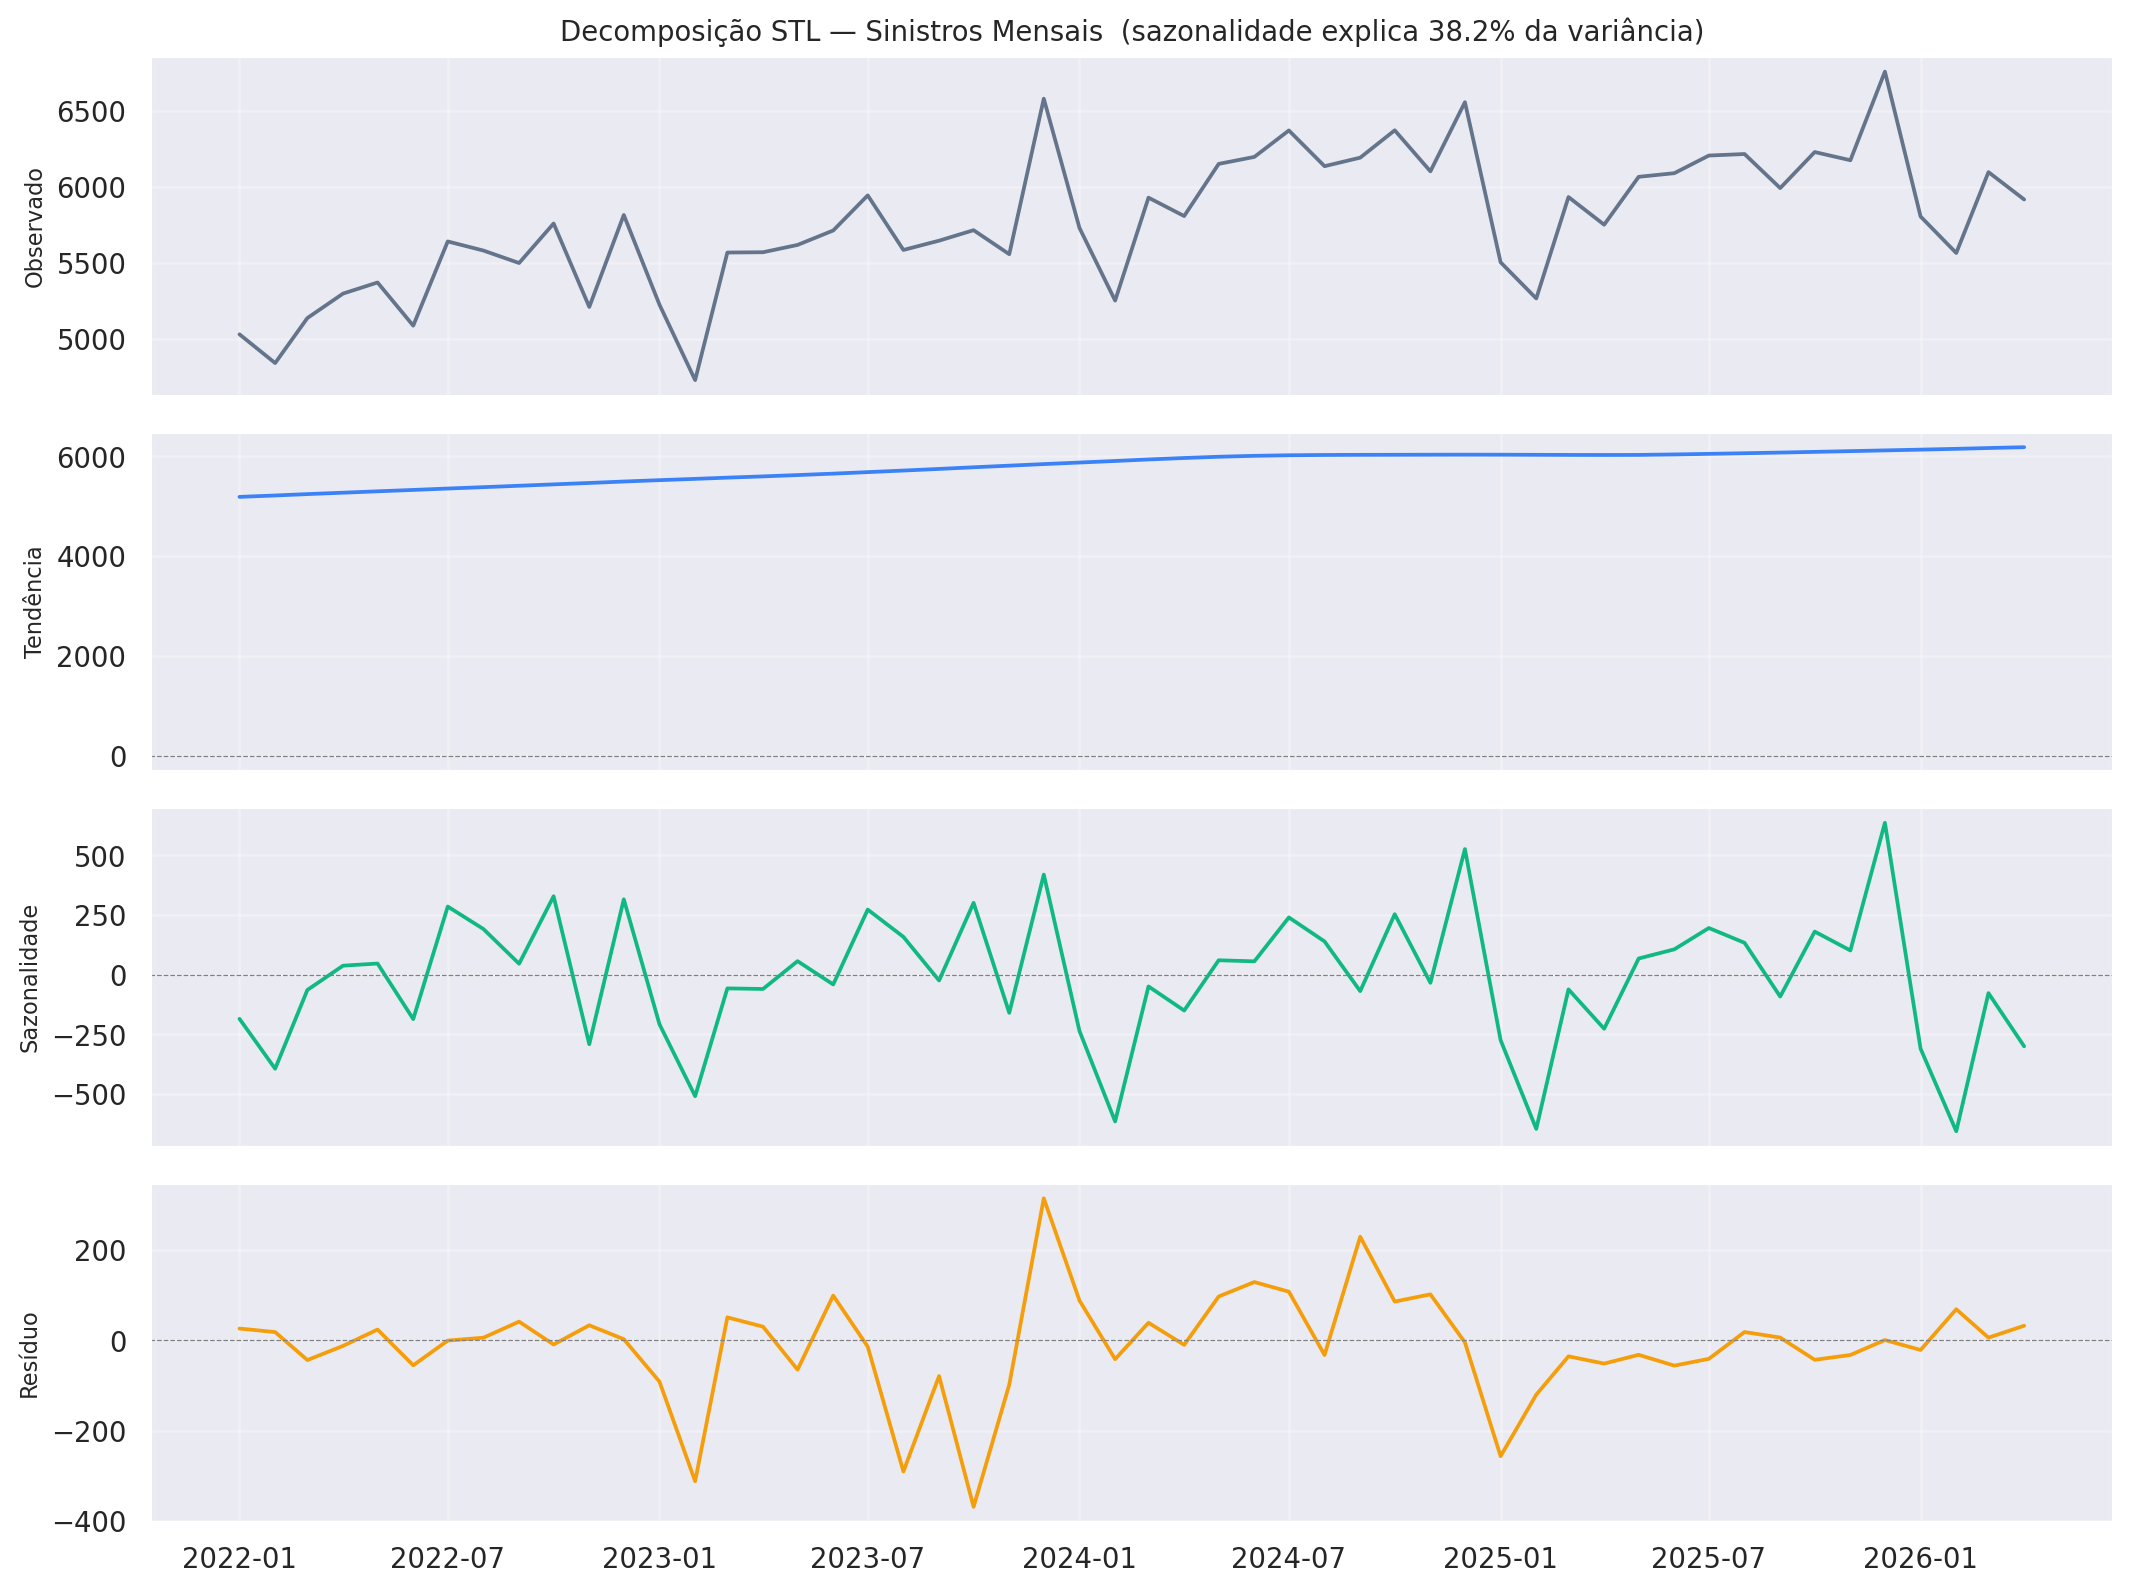

In [5]:
from IPython.display import Image
Image(str(result['stl_figure_path']))

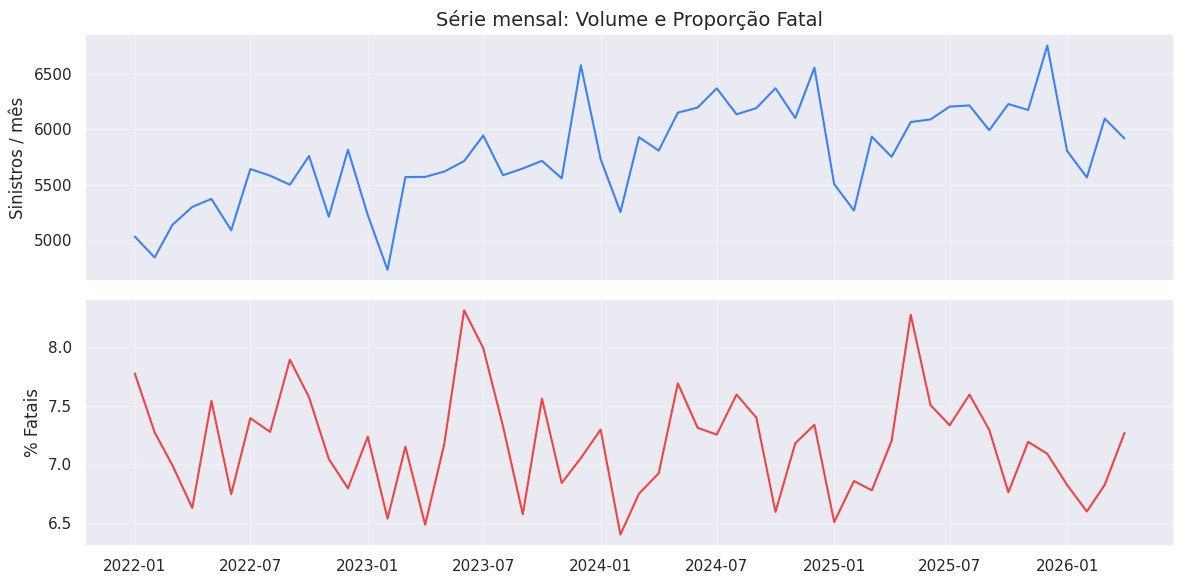

In [6]:
import matplotlib.pyplot as plt

monthly = result['monthly_series']

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(monthly.index, monthly['total'], color='#3b82f6', linewidth=1.5)
axes[0].set_ylabel('Sinistros / mês')
axes[0].set_title('Série mensal: Volume e Proporção Fatal')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly.index, monthly['proporcao_fatal'] * 100, color='#ef4444', linewidth=1.5)
axes[1].set_ylabel('% Fatais')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

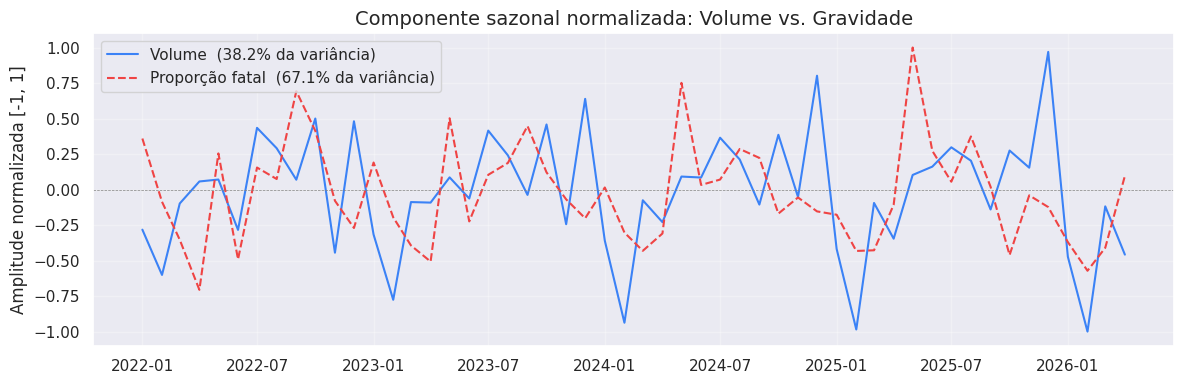

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

vol_norm = stl_vol['seasonal'] / stl_vol['seasonal'].abs().max()
sev_norm = stl_sev['seasonal'] / stl_sev['seasonal'].abs().max()

ax.plot(vol_norm.index, vol_norm.values, color='#3b82f6', linewidth=1.5,
        label=f"Volume  ({stl_vol['pct_variance_seasonal']:.1%} da variância)")
ax.plot(sev_norm.index, sev_norm.values, color='#ef4444', linewidth=1.5, linestyle='--',
        label=f"Proporção fatal  ({stl_sev['pct_variance_seasonal']:.1%} da variância)")
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Componente sazonal normalizada: Volume vs. Gravidade')
ax.set_ylabel('Amplitude normalizada [-1, 1]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretação STL

- O componente sazonal do **volume** concentra parcela relevante da variância — pico nos meses de verão/férias e vales intermediários confirmam sazonalidade anual de fluxo.
- O componente sazonal da **proporção fatal** explica muito menos variância, indicando que a gravidade dos sinistros **não** segue o mesmo padrão cíclico que o volume.
- Conclusão: **a sazonalidade de H2 é um fenômeno de volume, não de gravidade**. O aumento de fatalidades em períodos intensos é proporcional ao aumento do volume total, e não resultado de sinistros intrinsecamente mais graves nessas datas.